In [13]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2
from imports import *

In [14]:
from config import dir_config
from src.utils import pmf_utils, classification_utils

raw_dir = Path(dir_config.data.raw)
processed_dir = Path(dir_config.data.processed)

filtered_data = pd.read_csv(Path(processed_dir, "processed_all_data_accu_60_filtered.csv"), index_col=None)
processed_metadata = pd.read_csv(Path(processed_dir, "processed_metadata_all_data_accu_60.csv"), index_col=None)


In [15]:
subjects_map, grp_indices = classification_utils.get_subject_classification_ids(processed_metadata)


PD subjects with ON+OFF sessions: 41
PD subjects with UPDRS subtype: 22
All PD subjects:           41
  Tremor dominant:         11 	 ['P3' 'P6' 'P7' 'P11' 'P12' 'P17' 'P18' 'P19' 'P29' 'P31' 'P32']
  Brady dominant:          10 	 ['P1' 'P4' 'P9' 'P13' 'P20' 'P22' 'P23' 'P28' 'P33' 'P34']
  Intermediate:            1 	 ['P24']
HC subjects:               18 	 ['HC1' 'HC3' 'HC6' 'HC7' 'HC8' 'HC9' 'HC12' 'HC13' 'AV' 'BC' 'BF' 'EM'
 'ES' 'GF' 'GP' 'JA' 'MRM' 'SY']


## Plot group-wise psychometric function

## Statistical tests on PMF params

In [16]:
psych_columns = [
    "overall_bias",
    "overall_psych_alpha",
    "overall_psych_beta",
]

psych_params = processed_metadata[psych_columns]


## Group comparisons on overall PMF parameters

Between-group (unpaired): HC vs Tremor OFF, HC vs Brady OFF, Tremor OFF vs Brady OFF — Mann-Whitney U.  
Within-group (paired): Tremor OFF vs ON, Brady OFF vs ON — Wilcoxon signed-rank.  
Bonferroni correction across all 5 comparisons per parameter.

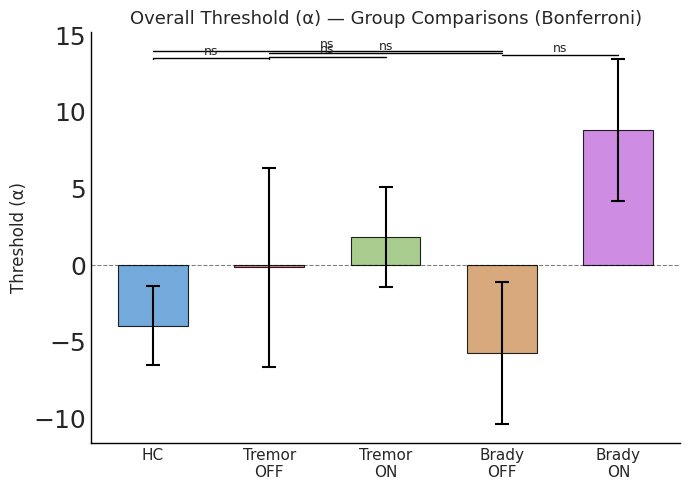

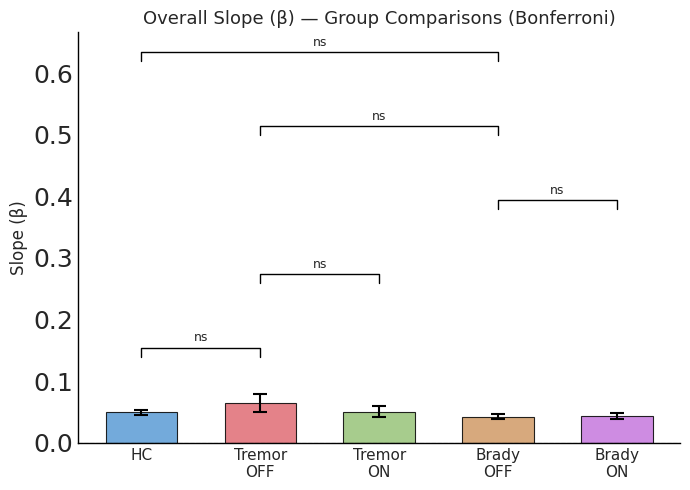

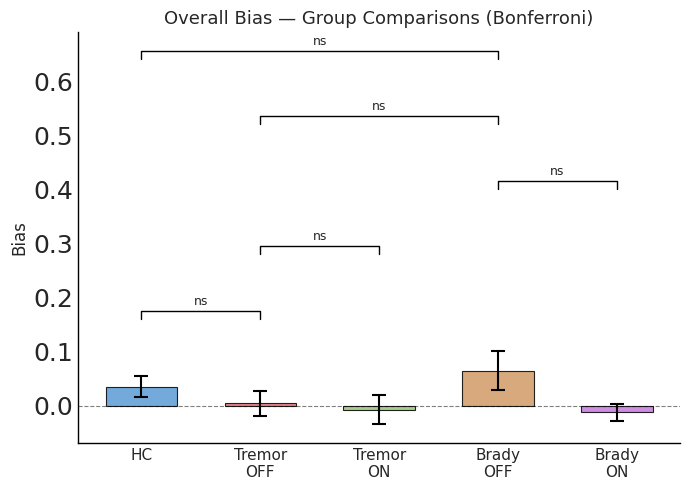

In [17]:
from scipy import stats as scipy_stats
from statsmodels.stats.multitest import multipletests

overall_vars = {
    "overall_psych_alpha": "Threshold (α)",
    "overall_psych_beta":  "Slope (β)",
    "overall_bias":        "Bias",
}

plot_groups = ["healthy", "tremor_off", "tremor_on", "brady_off", "brady_on"]
group_labels = {
    "healthy":    "HC",
    "tremor_off": "Tremor\nOFF",
    "tremor_on":  "Tremor\nON",
    "brady_off":  "Brady\nOFF",
    "brady_on":   "Brady\nON",
}
group_colors = ["#5B9BD5", "#E06C75", "#98C379", "#D19A66", "#C678DD"]

# (group_a, group_b, paired)
comparisons = [
    ("healthy",    "tremor_off", False),  # unpaired → Mann-Whitney U
    ("tremor_off", "tremor_on",  True),   # paired   → Wilcoxon
    ("healthy",    "brady_off",  False),  # unpaired → Mann-Whitney U
    ("brady_off",  "brady_on",   True),   # paired   → Wilcoxon
    ("tremor_off", "brady_off",  False),  # unpaired → Mann-Whitney U
]
group_xi = {g: i for i, g in enumerate(plot_groups)}


def _sig_stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"


def _get_paired(col, grp_a, grp_b):
    """Align OFF/ON series by subject position, drop NaNs jointly to preserve pairing."""
    a = processed_metadata.loc[grp_indices[grp_a], col].reset_index(drop=True)
    b = processed_metadata.loc[grp_indices[grp_b], col].reset_index(drop=True)
    paired = pd.DataFrame({"a": a, "b": b}).dropna()
    return paired["a"].values, paired["b"].values


for col, col_label in overall_vars.items():
    is_bias = col == "overall_bias"

    # collect raw p-values for Bonferroni correction
    raw_ps = []
    for grp_a, grp_b, paired in comparisons:
        if paired:
            a, b = _get_paired(col, grp_a, grp_b)
            if is_bias:
                a, b = a - 0.5, b - 0.5
            _, p = scipy_stats.wilcoxon(a, b)
        else:
            a = processed_metadata.loc[grp_indices[grp_a], col].dropna().values
            b = processed_metadata.loc[grp_indices[grp_b], col].dropna().values
            if is_bias:
                a, b = a - 0.5, b - 0.5
            _, p = scipy_stats.mannwhitneyu(a, b, alternative="two-sided")
        raw_ps.append(p)

    _, corr_ps, _, _ = multipletests(raw_ps, method="bonferroni")

    # bar plot
    fig, ax = plt.subplots(figsize=(7, 5))
    bar_tops = []

    for xi, (grp, color) in enumerate(zip(plot_groups, group_colors)):
        vals = processed_metadata.loc[grp_indices[grp], col].dropna().values
        if is_bias:
            vals = vals - 0.5
        mean = vals.mean()
        sem  = scipy_stats.sem(vals)
        ax.bar(xi, mean, color=color, edgecolor="k", linewidth=0.8, width=0.6, alpha=0.85)
        ax.errorbar(xi, mean, yerr=sem, fmt="none", color="k", capsize=5, elinewidth=1.5, capthick=1.5)
        bar_tops.append(mean + sem)

    # stack brackets shortest span first to avoid overlap
    span_order = sorted(
        enumerate(comparisons), key=lambda x: abs(group_xi[x[1][1]] - group_xi[x[1][0]])
    )
    bracket_base = max(bar_tops) + 0.06
    bracket_step = 0.12

    for rank, (i, (grp_a, grp_b, _)) in enumerate(span_order):
        xi_a, xi_b = group_xi[grp_a], group_xi[grp_b]
        y = bracket_base + rank * bracket_step
        p_adj = corr_ps[i]
        ax.plot([xi_a, xi_a, xi_b, xi_b], [y, y + 0.015, y + 0.015, y], color="k", lw=1)
        ax.text((xi_a + xi_b) / 2, y + 0.02, _sig_stars(p_adj), ha="center", va="bottom", fontsize=9)

    ax.axhline(0, color="k", lw=0.8, ls="--", alpha=0.5)
    ax.set_xticks(range(len(plot_groups)))
    ax.set_xticklabels([group_labels[g] for g in plot_groups], fontsize=11)
    ax.set_ylabel(col_label, fontsize=12)
    ax.set_title(f"Overall {col_label} — Group Comparisons (Bonferroni)", fontsize=13)
    ax.grid(False)
    plt.tight_layout()
    plt.show()
